In [1]:
from google.colab import files
uploaded = files.upload()

Saving Agriculture-pests.zip to Agriculture-pests.zip


In [20]:
import zipfile

zip_path = "/content/Agriculture-pests.zip"
extract_path = "/content/pest_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [22]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    "/content/pest_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "/content/pest_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4399 images belonging to 12 classes.
Found 1095 images belonging to 12 classes.


In [23]:
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cnn_history = cnn.fit(train_data, validation_data=val_data, epochs=10)

cnn_acc = cnn.evaluate(val_data)[1]
print("CNN Accuracy:", cnn_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.1107 - loss: 2.4768 - val_accuracy: 0.1826 - val_loss: 2.3850
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.1991 - loss: 2.3187 - val_accuracy: 0.2530 - val_loss: 2.2253
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.2585 - loss: 2.1577 - val_accuracy: 0.3416 - val_loss: 2.0214
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.3089 - loss: 2.0467 - val_accuracy: 0.3699 - val_loss: 1.9364
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.3346 - loss: 1.9697 - val_accuracy: 0.3425 - val_loss: 1.9422
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.3594 - loss: 1.9122 - val_accuracy: 0.3662 - val_loss: 1.8676
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.3764 - loss: 1.8491 - val_accuracy: 0.4064 - val_loss: 1.7782
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.3962 - loss: 1.7988 - val_accu

In [24]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

model_mobilenet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model_mobilenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

mn_history = model_mobilenet.fit(train_data, validation_data=val_data, epochs=8)

mn_acc = model_mobilenet.evaluate(val_data)[1]
print("MobileNetV2 Accuracy:", mn_acc)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 92s 621ms/step - accuracy: 0.5422 - loss: 1.4459 - val_accuracy: 0.7397 - val_loss: 0.8210
Epoch 2/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 86s 623ms/step - accuracy: 0.7008 - loss: 0.9254 - val_accuracy: 0.7717 - val_loss: 0.7122
Epoch 3/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 85s 615ms/step - accuracy: 0.7281 - loss: 0.8359 - val_accuracy: 0.7689 - val_loss: 0.6680
Epoch 4/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 90s 652ms/step - accuracy: 0.7540 - loss: 0.7474 - val_accuracy: 0.7689 - val_loss: 0.6747
Epoch 5/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 85s 619ms/step - accuracy: 0.7570 - loss: 0.7126 - val_accuracy: 0.7973 - val_loss: 0.6250
Epoch 6/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 87s 630ms/step - accuracy: 0.7720 - loss: 0.6794 - val_accuracy: 0.7854 - val_loss: 0.6406
Epoch 7/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 89s 648ms/step - accuracy: 0.7825 - loss: 0.6433 - val_accuracy: 0.7808 - val_loss: 0.6450
Epoch 8/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 84

In [25]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

rn_history = model_resnet.fit(train_data, validation_data=val_data, epochs=8)

rn_acc = model_resnet.evaluate(val_data)[1]
print("ResNet50 Accuracy:", rn_acc)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.0905 - loss: 2.5172 - val_accuracy: 0.0904 - val_loss: 2.4795
Epoch 2/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.0932 - loss: 2.4816 - val_accuracy: 0.0986 - val_loss: 2.4796
Epoch 3/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.0893 - loss: 2.4787 - val_accuracy: 0.1142 - val_loss: 2.4776
Epoch 4/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.0918 - loss: 2.4776 - val_accuracy: 0.0913 - val_loss: 2.4765
Epoch 5/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.0980 - loss: 2.4758 - val_accuracy: 0.1087 - val_loss: 2.4725
Epoch 6/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.0971 - loss: 2.4735 - val_accuracy: 0.0968 - val_loss: 2.4704
Epoch 7/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.1039 - loss: 2.4714 - val_accuracy: 0.1470 - val_loss: 2.4668
Epoch 8/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step -

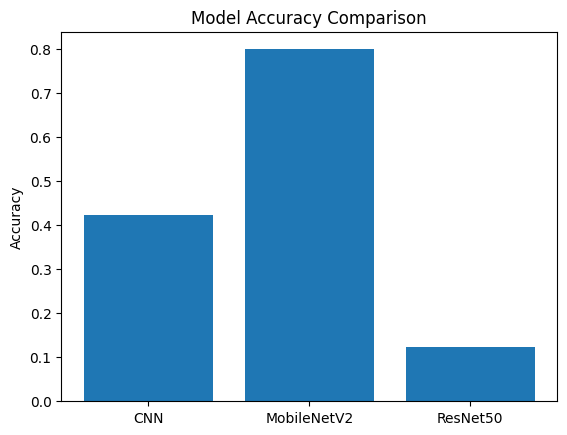

In [26]:
models = ["CNN", "MobileNetV2", "ResNet50"]
accuracies = [cnn_acc, mn_acc, rn_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

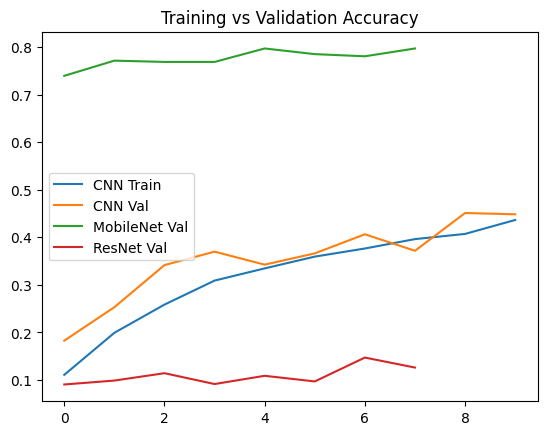

In [27]:
plt.figure()
plt.plot(cnn_history.history['accuracy'], label='CNN Train')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val')

plt.plot(mn_history.history['val_accuracy'], label='MobileNet Val')
plt.plot(rn_history.history['val_accuracy'], label='ResNet Val')

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [28]:
#Since MobileNetV2 is your best model, we’ll optimize it using hyperparameter tuning + fine-tuning.
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Freeze base model first
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [30]:
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 92s 617ms/step - accuracy: 0.6254 - loss: 1.2725 - val_accuracy: 0.7744 - val_loss: 0.7024 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 85s 616ms/step - accuracy: 0.7622 - loss: 0.7543 - val_accuracy: 0.7826 - val_loss: 0.6752 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 89s 645ms/step - accuracy: 0.7825 - loss: 0.6521 - val_accuracy: 0.7826 - val_loss: 0.7116 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 138s 618ms/step - accuracy: 0.8063 - loss: 0.5813 - val_accuracy: 0.7854 - val_loss: 0.6962 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 86s 627ms/step - accuracy: 0.8427 - loss: 0.4753 - val_accuracy: 0.7973 - val_loss: 0.6542 - learning_rate: 3.0000e-04
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 84s 607ms/step - accuracy: 0.8593 - loss: 0.4121 - val_accuracy: 0.7781 - val_loss: 0.7269 - learning_rate: 3.0000e-04
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 84s 607ms/step - accu

In [38]:
#Phase 2 optimization
#Augmentation
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

augmentation = models.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

In [39]:
# Unfreeze top layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a better LR for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # Higher than before — will decay naturally
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Create FRESH callbacks — do NOT reuse the old ones
early_stop2 = EarlyStopping(
    monitor='val_accuracy',      # Monitor accuracy, not just loss
    patience=5,                  # More patience for fine-tuning
    restore_best_weights=True
)

reduce_lr2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                  # Less aggressive reduction
    patience=3,
    min_lr=1e-7
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,                   # More epochs — fine-tuning is slow
    callbacks=[early_stop2, reduce_lr2]
)

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 122s 802ms/step - accuracy: 0.8316 - loss: 0.4960 - val_accuracy: 0.7397 - val_loss: 1.1047 - learning_rate: 1.0000e-04
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 108s 786ms/step - accuracy: 0.8666 - loss: 0.4108 - val_accuracy: 0.7489 - val_loss: 1.0030 - learning_rate: 1.0000e-04
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 107s 778ms/step - accuracy: 0.8734 - loss: 0.3617 - val_accuracy: 0.7872 - val_loss: 0.8405 - learning_rate: 1.0000e-04
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 109s 787ms/step - accuracy: 0.8995 - loss: 0.2893 - val_accuracy: 0.7680 - val_loss: 0.8819 - learning_rate: 1.0000e-04
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 112s 814ms/step - accuracy: 0.9125 - loss: 0.2596 - val_accuracy: 0.8018 - val_loss: 0.7891 - learning_rate: 1.0000e-04
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 108s 782ms/step - accuracy: 0.9300 - loss: 0.2058 - val_accuracy: 0.7963 - val_loss: 0.8238 - learning_rate: 1.0000e-04
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 

In [40]:
loss, acc = model.evaluate(val_data)
print("Optimized MobileNetV2 Accuracy:", acc)

35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 460ms/step - accuracy: 0.7982 - loss: 0.7901
Optimized MobileNetV2 Accuracy: 0.7981734871864319


In [42]:
best_val_acc = max(history2.history['val_accuracy'])
print(f"Best val accuracy (fine-tuning): {best_val_acc:.4f}")

Best val accuracy (fine-tuning): 0.8018


In [43]:
# Save in Keras format
model.save('mobilenetv2_model.keras')

# Download to your computer
from google.colab import files
files.download('mobilenetv2_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>